# **📘 GIỚI THIỆU BÀI TOÁN**

***BÀI TẬP MỞ RỘNG: BAYESIAN NETWORK***

* **Giảng viên hướng dẫn**  
  * **Giảng viên: TS.Lê Thành Sách**

* **Nhóm MNTV:**
  * Tên: Huỳnh Đức Nhân - MSSV: 2312420
  * Tên: Nguyễn Thiện Minh - MSSV: 2312097
  * Tên: Nguyễn Lưu Khánh Trình - MSSV: 2313638
  * Tên: Lê Công Vinh - MSSV: 2313912

* **Giới thiệu bài toán**
  * Hiện thực mô hình Bayesian Network, cài đặt các thuật toán suy luận (inference) gồm: suy luận chính xác và suy luận xấp xỉ cơ bản.

  * Ứng dụng: giải một bài toán dự đoán một người có có bị trầm cảm hay không dựa trên quan hệ nhân quả trong dữ liệu. Ở đây nhóm chúng tôi sử dụng bộ dữ liệu **Student Depression Dataset** chứa các thông tin về suy nghĩ tự tử, áp lực học tập, căng thẳng trong công việc, độ hài lòng trong học tập,...

  * Thông tin về bộ dữ liệu:
    * Tổng số mẫu: 27,901 mẫu.
    * Số feature: 18.
    * Format dữ liệu: Numeric và categorical.
    * Link dataset: [Kaggle - **Student Depression Dataset**](https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset/data?select=student_depression_dataset.csv)

*  **Mục tiêu của bài toán**
    * Hiện thực mô hình Bayesian Network, cài đặt các thuật toán suy luận gồm: suy luận chính xác và suy luận xấp xỉ cơ bản.
    * giải một bài toán dự đoán một người có có bị có mắc phải trầm cảm hay không dựa trên quan hệ nhân quả trong dữ liệu.




****

# **📌 Cài đặt & import các thư viện**

## *Giới thiệu các thư viện sử dụng*
Trong quá trình xây dựng và huấn luyện mô hình Machine Learning, nhóm đã sử dụng nhiều thư viện Python phổ biến, hỗ trợ mạnh mẽ cho việc xử lý dữ liệu, trực quan hóa cũng như xây dựng và đánh giá mô hình. Cụ thể:
- numpy (np): thư viện xử lý mảng số học, hỗ trợ các phép toán ma trận, đại số tuyến tính – nền tảng cho hầu hết các tính toán trong Machine Learning.
- pandas (pd): cung cấp cấu trúc dữ liệu DataFrame thuận tiện cho việc xử lý, làm sạch, và phân tích dữ liệu.
- matplotlib.pyplot (plt) và seaborn (sns): dùng để trực quan hóa dữ liệu, hỗ trợ vẽ biểu đồ, biểu diễn phân bố và mối quan hệ giữa các biến.
- sklearn.pipeline (Pipeline) và sklearn.compose (ColumnTransformer): dùng để xây dựng pipeline học máy.
-  sklearn.model_selection (train_test_split): công cụ chia dữ liệu thành tập huấn luyện và tập kiểm thử.
- sklearn.impute (SimpleImputer): cung cấp một số công cụ impute đơn giản.
- sklearn.preprocessing (StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder): các kỹ thuật chuẩn hóa dữ liệu, xử lý dữ liệu phân loại để cải thiện hiệu quả huấn luyện mô hình.
- sklearn.linear_model (LinearRegression): mô hình hồi quy tuyến tính, một thuật toán cơ bản trong học máy.
- sklearn.ensemble (RandomForestRegressor): thuật toán hồi quy dựa trên rừng ngẫu nhiên (ensemble learning), cho độ chính xác cao và khả năng khái quát tốt.
- sklearn.neural_network (MLPRegressor): mô hình hồi quy sử dụng mạng nơ-ron truyền thẳng đa lớp (Multi-Layer Perceptron).
- sklearn.svm (SVR): mô hình hồi quy dựa trên máy vector hỗ trợ (Support Vector Regression).
- sklearn.metrics (mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score): các thước đo đánh giá hiệu năng của mô hình, bao gồm sai số bình phương trung bình, sai số tuyệt đối trung bình, và hệ số xác định R2
- warnings: dùng để quản lý và ẩn bớt các cảnh báo không cần thiết trong quá trình chạy chương trình.
Ngoài ra, để tăng tính trực quan của biểu đồ, nhóm thiết lập style hiển thị cho matplotlib bằng plt.style.use('seaborn-v0_8') và thiết lập bảng màu cho seaborn bằng sns.set_palette("husl").

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
import sklearn
import networkx as nx
import random
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
# Thiết lập style cho matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
sklearn.set_config(enable_metadata_routing=True)

# **Xây dựng thư viện Bayesian NetWork**

## 1. Xây dựng thư viện Graph


Trong phần này, chúng ta xây dựng một **lớp `Graph`** đơn giản bằng Python để làm việc với đồ thị có hướng (Directed Graph).  
Mục tiêu chính là hỗ trợ:
- **Thêm node và cạnh có hướng**
- **Truy xuất danh sách cha (`parents`) và con (`children`) của một node**
- **Thực hiện sắp xếp topo (Topological Sort) trên DAG**
- Hỗ trợ in ra cấu trúc graph dưới dạng danh sách kề.

Lớp `Graph` này có thể sử dụng để làm nền tảng cho các ứng dụng như:
- Mạng Bayes (Bayesian Network)
- Phân tích đồ thị phụ thuộc
- Thuật toán lập lịch (scheduling) dựa trên quan hệ phụ thuộc


In [ ]:
class Graph:
    def __init__(self):
        # adjacency list: {node: [list of children]}
        self.adj = {}
        self.back = {}

    def add_node(self, node):
        """Thêm node mới vào graph"""
        if node not in self.adj:
            self.adj[node] = []
            self.back[node] = []

    def add_edge(self, u, v):
        """Thêm cạnh có hướng u -> v (u là parent, v là child)"""
        if u not in self.adj:
            self.add_node(u)
        if v not in self.adj:
            self.add_node(v)
        self.adj[u].append(v)
        self.back[v].append(u)

    def get_parents(self, node):
        """Trả về danh sách cha (parents) của node"""
        return self.back.get(node, [])

    def get_children(self, node):
        """Trả về danh sách con (children) của node"""
        return self.adj.get(node, [])

    def topological_sort(self):
        """Sắp xếp topo các node trong DAG"""
        visited = set()
        stack = []

        def dfs(u):
            if u in visited:
                return
            visited.add(u)
            for v in self.adj.get(u, []):
                dfs(v)
            stack.append(u)

        for node in self.adj:
            dfs(node)

        stack.reverse()
        return stack

    def __str__(self):
        return "\n".join([f"{u} -> {self.adj[u]}" for u in self.adj])

## 2. Xây dựng thư viện Bayesian NetWork

# 📌 Giới thiệu lớp `BayesianNetwork`

Đoạn code trên cài đặt một lớp **BayesianNetwork** trong Python để mô phỏng **Mạng Bayes** – một mô hình đồ thị xác suất biểu diễn mối quan hệ nhân quả giữa các biến ngẫu nhiên.  

## ⚙️ Các thành phần chính:
- `add_variable(node, parents, domain, cpt)`: Thêm biến vào mạng cùng với miền giá trị và bảng xác suất có điều kiện (CPT).
- `probability(node, value, assignment)`: Tính xác suất có điều kiện của một node khi biết giá trị của các biến cha.
- `joint_probability(assignment)`: Tính xác suất chung của một gán giá trị cho toàn bộ mạng.
- `query(Q, evidence)`: Truy vấn phân phối hậu nghiệm **P(Q | evidence)** bằng phương pháp **suy luận chính xác**.
- `approximate_query(Q, evidence, N)`: Truy vấn phân phối hậu nghiệm bằng phương pháp **Monte Carlo sampling** (ước lượng xấp xỉ).
- `visualize()`: Vẽ đồ thị mạng Bayes kèm theo bảng CPT cho từng node để trực quan hóa cấu trúc và xác suất.
- `_format_cpt(node)`: Hỗ trợ hiển thị CPT của một biến ở dạng dễ đọc.

## 🧩 Ứng dụng:
- Biểu diễn và suy luận trong các hệ thống thông minh.
- Dự đoán dựa trên dữ liệu quan sát (evidence).
- Trực quan hóa mối quan hệ xác suất giữa các biến.  

💡 Đây là một nền tảng cơ bản để xây dựng các ứng dụng như **hệ chuyên gia, dự đoán y tế, chẩn đoán sự cố, phân tích dữ liệu** trong nhiều lĩnh vực khác nhau.


In [ ]:
class BayesianNetwork(Graph):
    def __init__(self):
        super().__init__()
        self.cpt = {}      # {node: {(parent_values): {value: P}}}
        self.domains = {}  # {node: [possible_values]}

    def add_variable(self, node, parents, domain, cpt):
        """
        Thêm biến với CPT
        - node: tên biến
        - parents: danh sách cha
        - domain: danh sách giá trị có thể (list)
        - cpt: dict {tuple(parent_values): {value: prob}}
               Ví dụ: {"Weather": ["Sunny", "Rainy"],
                       CPT = {(): {"Sunny": 0.7, "Rainy": 0.3}}}
        """
        self.add_node(node)
        for p in parents:
            self.add_edge(p, node)
        self.cpt[node] = cpt
        self.domains[node] = domain

    def probability(self, node, value, assignment):
        """Trả về P(node=value | parents)"""
        parents = self.get_parents(node)
        parent_values = tuple(assignment[p] for p in parents)
        return self.cpt[node][parent_values][value]

    def joint_probability(self, assignment):
        """Tính P(assignment) = tích P(node | parents)"""
        prob = 1.0
        for node in self.adj:
            prob *= self.probability(node, assignment[node], assignment)
        return prob

    def query(self, Q, evidence):
        """
        Truy vấn P(Q | evidence)
        - Q: biến cần hỏi
        - evidence: dict {node: value}
        """
        dist = {v: 0.0 for v in self.domains[Q]}

        # duyệt tất cả tổ hợp giá trị cho các biến
        for values in itertools.product(*[self.domains[v] for v in self.adj]):
            assignment = dict(zip(self.adj.keys(), values))
            # check khớp evidence
            if all(assignment[e] == evidence[e] for e in evidence):
                dist[assignment[Q]] += self.joint_probability(assignment)

        # chuẩn hóa
        norm = sum(dist.values())
        for k in dist:
            dist[k] /= norm
        return dist

    def approximate_query(self, Q, evidence, N=1000):
        dist = {v: 0.0 for v in self.domains[Q]}
        nodes = self.topological_sort()

        for _ in range(N):
            weight = 1.0
            sample = {}

            for node in nodes:
                parents = self.get_parents(node)
                parent_values = tuple(sample[p] for p in parents)

                probs = self.cpt[node][parent_values]

                if node in evidence:
                    val = evidence[node]
                    sample[node] = val
                    weight *= probs[val]  # nhân trọng số
                else:
                    # chọn giá trị ngẫu nhiên theo phân phối
                    values, pvals = zip(*probs.items())
                    val = random.choices(values, weights=pvals, k=1)[0]
                    sample[node] = val

            dist[sample[Q]] += weight

        # chuẩn hóa
        norm = sum(dist.values())
        for k in dist:
            dist[k] /= norm
        return dist

    def log_query(self, Q, evidence):
        import math
        import itertools

        def _logaddexp(a, b):
            if a == float('-inf'): return b
            if b == float('-inf'): return a
            m = a if a > b else b
            return m + math.log(math.exp(a - m) + math.exp(b - m))

        def _logsumexp_list(values):
            out = float('-inf')
            for v in values:
                out = _logaddexp(out, v)
            return out

        # init log distribution
        log_dist = {v: float('-inf') for v in self.domains[Q]}
        nodes = list(self.adj.keys())

        # log CPT
        def log_prob(node, val, assignment):
            parents = self.get_parents(node)
            parent_vals = tuple(assignment[p] for p in parents)
            p = self.cpt[node][parent_vals][val]
            return math.log(p)

        # log joint
        def log_joint(assignment):
            s = 0.0
            for node in nodes:
                s += log_prob(node, assignment[node], assignment)
            return s

        # enumerate assignments
        for values in itertools.product(*[self.domains[v] for v in nodes]):
            assignment = dict(zip(nodes, values))

            # evidence check
            if any(assignment[e] != evidence[e] for e in evidence):
                continue

            q_val = assignment[Q]
            lj = log_joint(assignment)

            # accumulate with logaddexp
            log_dist[q_val] = _logaddexp(log_dist[q_val], lj)

        # normalization via logsumexp
        log_Z = _logsumexp_list(log_dist.values())
        for v in log_dist:
            log_dist[v] -= log_Z

        return log_dist



    def visualize(self, hide_table = False):
        """Vẽ mạng Bayesian với CPT cho từng node"""
        G = nx.DiGraph()

        # thêm các node và cạnh
        for node in self.adj:
            G.add_node(node)
            for child in self.adj[node]:
                G.add_edge(node, child)

        pos = nx.spring_layout(G, seed=42)  # vị trí node
        plt.figure(figsize=(12, 8))

        # vẽ graph
        nx.draw_networkx_nodes(G, pos, node_size=1800, node_color="lightblue")
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

        # vẽ cạnh với mũi tên rõ ràng
        nx.draw_networkx_edges(G, pos,
            arrowstyle="-|>",
            arrowsize=20,
            width=2,
            min_source_margin=20,   # lùi khỏi tâm node nguồn
            min_target_margin=20    # lùi khỏi tâm node đích
        )

        if not hide_table:
            # vẽ CPT gần node
            for node, (x, y) in pos.items():
                cpt_str = self._format_cpt(node)
                plt.text(
                    x, y - 0.15, cpt_str,
                    ha="center", va="top",
                    fontsize=8,
                    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
                )

        plt.axis("off")
        plt.show()

    def _format_cpt(self, node):
        """Chuyển CPT của node thành string gọn gàng"""
        lines = []
        for parent_vals, probs in self.cpt[node].items():
            parent_str = ", ".join(f"{p}={v}" for p, v in zip(self.get_parents(node), parent_vals))
            if not parent_str:
                parent_str = "∅"
            prob_str = ", ".join(f"{val}:{p:.2f}" for val, p in probs.items())
            lines.append(f"[{parent_str}] → {prob_str}")
        return "\n".join(lines)

## 3. Xây dựng thư viện Bayesian NetWork kết hợp với dữ liệu dạng bảng

# 🧠 BayesianNetworkTable - Thư viện mạng Bayes từ dữ liệu

Trong phần này, chúng ta sẽ xây dựng một thư viện **BayesianNetworkTable**, được kế thừa từ lớp `BayesianNetwork`.  
Thư viện này cho phép:

- Nhập vào một **DataFrame** (dataset).
- Tự động sinh các node từ dữ liệu (`add_variable_from_data`).
- Tính toán **CPT (Conditional Probability Table)** dựa trên dữ liệu bằng **MLE (Maximum Likelihood Estimation)**.
- Dự đoán biến mục tiêu dựa trên bằng chứng (`predict`) với 2 cách:
  - **Exact inference** (uyển tính xác suất đúng).
  - **Approximate inference** (xấp xỉ bằng sampling).
- Đánh giá mô hình bằng các tiêu chí **MSE, MAE, RMSE, R²**.
- Hỗ trợ rời rạc hóa dữ liệu liên tục (`discretize_column`).

---


In [ ]:
class BayesianNetworkTable(BayesianNetwork):
    def __init__(self, dataset: pd.DataFrame):
        super().__init__()
        self.dataset = dataset.copy()

    def add_variable_from_data(self, node, parents=None):
        """
        Tạo node từ dataset, domain lấy từ các giá trị duy nhất trong cột
        """
        if parents is None:
            parents = []
        domain = sorted(self.dataset[node].unique().tolist())
        self.add_node(node)
        for p in parents:
            self.add_edge(p, node)
        self.domains[node] = domain
        # CPT sẽ được tính sau bằng fit_cpt()
        self.cpt[node] = {}

    def fit_cpt(self, node, method="MLE", smoothing=0.0, alpha=1.0, bias_table=None):
        """
        Tính CPT cho 1 node theo:
          - MLE (có thể smoothing)
          - MAP (Dirichlet prior: alpha hoặc bias_table)

        Args:
            method (str): "MLE" hoặc "MAP"
            smoothing (float): Laplace smoothing; dùng cho MLE
            alpha (float): Dirichlet prior nếu dùng MAP
            bias_table (dict): {(parent_vals): {value: alpha}} tùy chỉnh chi tiết

        """
        parents = self.get_parents(node)
        domain = self.domains[node]

        if not parents:
            # -------- Node không có parents ----------
            counts = self.dataset[node].value_counts().reindex(domain, fill_value=0)
            total = counts.sum()

            if method == "MLE":
                # MLE + smoothing (Laplace)
                probs = {
                    val: (counts[val] + smoothing) / (total + smoothing * len(domain))
                    for val in domain
                }

            elif method == "MAP":
                # Dirichlet prior: α > 0
                probs = {
                    val: (counts[val] + alpha) / (total + alpha * len(domain))
                    for val in domain
                }

            self.cpt[node][()] = probs
            return

        # -------- Node có parents -----------
        group = self.dataset.groupby(parents + [node]).size().reset_index(name="count")
        totals = self.dataset.groupby(parents).size().reset_index(name="total")
        merged = pd.merge(group, totals, on=parents)

        # khởi tạo CPT rỗng
        for pv in itertools.product(*[self.domains[p] for p in parents]):
            self.cpt[node][pv] = {v: 0 for v in domain}

        # đổ counts vào CPT
        for _, row in merged.iterrows():
            pv = tuple(row[p] for p in parents)
            self.cpt[node][pv][row[node]] = row["count"]

        # tính xác suất
        for pv in self.cpt[node]:
            counts = self.cpt[node][pv]
            total = sum(counts.values())

            if method == "MLE":
                probs = {
                    val: (counts[val] + smoothing) / (total + smoothing * len(domain))
                    for val in domain
                }

            elif method == "MAP":
                if bias_table and pv in bias_table:
                    # MAP theo bảng bias
                    probs = {
                        val: (counts[val] + bias_table[pv].get(val, alpha))
                        for val in domain
                    }
                    norm = sum(probs.values())
                    probs = {v: probs[v] / norm for v in probs}
                else:
                    # MAP Dirichlet alpha đều
                    probs = {
                        val: (counts[val] + alpha)
                        for val in domain
                    }
                    norm = sum(probs.values())
                    probs = {v: probs[v] / norm for v in probs}

            self.cpt[node][pv] = probs


    def fit_all(self, method="MLE", **kwargs):
        """
        Tính CPT cho tất cả các node trong network.

        Args:
            method (str): "MLE" hoặc "MAP"
            smoothing (float): dùng cho MLE
            alpha (float): prior MAP
            bias_table (dict): prior chi tiết từng CPT
        """
        for node in self.domains:
            self.fit_cpt(node, method=method, **kwargs)

    def predict(self, Q, evidence, method="exact", N=1000):
        """
        Dự đoán giá trị có xác suất lớn nhất của biến Q dựa trên evidence.

        Args:
            Q (str): biến cần dự đoán
            evidence (dict): bằng chứng {node: value}
            method (str): "exact" (mặc định) hoặc "approximate"
            N (int): số mẫu dùng cho phương pháp xấp xỉ
        """
        if method == "exact":
            dist = self.query(Q, evidence)
        elif method == "approximate":
            dist = self.approximate_query(Q, evidence, N)
        elif method == "log":
            dist = self.log_query(Q, evidence)
        else:
            raise ValueError("method phải là 'exact' hoặc 'approximate' hoặc 'log'")

        return max(dist, key=dist.get), dist

    def evaluate(self, target, test_data: pd.DataFrame, method="exact", N=1000):
      """
      Đánh giá mô hình bằng Accuracy.
      """
      y_true = []
      y_pred = []

      # ánh xạ domain của target thành số
      domain = self.domains[target]
      mapping = {val: i for i, val in enumerate(domain)}

      for _, row in test_data.iterrows():
          evidence = {col: row[col] for col in test_data.columns if col != target}

          # phân phối hậu nghiệm
          if method == "exact":
              dist = self.query(target, evidence)
          elif method == "approximate":
              dist = self.approximate_query(target, evidence, N)
          elif method == "log":
              dist = self.log_query(target, evidence)
          else:
              raise ValueError("method phải là 'exact' hoặc 'approximate' hoặc 'log'")

          # dự đoán nhãn = argmax của dist
          pred_label = max(dist.items(), key=lambda x: x[1])[0]  # nhãn gốc
          y_pred.append(mapping[pred_label])

          # nhãn thật
          y_true.append(mapping[row[target]])

      y_true = np.array(y_true)
      y_pred = np.array(y_pred)

      acc = accuracy_score(y_true, y_pred)
      return {"Accuracy": acc}


    def discretize_column(self, column, bins=3, method="uniform", labels=None):
        """
        Biến đổi cột định lượng thành phân loại.

        Args:
            column (str): tên cột trong DataFrame.
            bins (int): số khoảng để chia.
            method (str): "uniform" (chia đều khoảng) hoặc "quantile" (chia theo phân vị).
            labels (list): danh sách nhãn cho các bins. Nếu None -> tự động.

        Trả về:
            None (cập nhật trực tiếp self.data[column]).
        """
        if method == "uniform":
            self.dataset[column] = pd.cut(self.dataset[column], bins=bins, labels=labels)
        elif method == "quantile":
            self.dataset[column] = pd.qcut(self.dataset[column], q=bins, labels=labels, duplicates="drop")
        else:
            raise ValueError("method phải là 'uniform' hoặc 'quantile'")

## *Tải dữ liệu*
Đầu tiên, nhóm tiến hành tải bộ dữ liệu **Student Depression Dataset** từ **Kaggle** thông qua thư viện `kagglehub`. Sau khi tải về, file dữ liệu có tên `student_depression_dataset.csv` được sử dụng để huấn luyện mô hình.  

- Sử dụng `kagglehub.dataset_download(...)` để tải bộ dữ liệu từ Kaggle.  
- Sử dụng `pandas.read_csv(...)` để đọc dữ liệu dưới dạng bảng.  

<h2><b>Thông tin các cột trong bộ dữ liệu</b></h2>

* **ID**: Unique identifier for each student
* **Demographics**: Age, Gender, City
* **Academic Indicators**: CGPA, Academic Pressure, Study Satisfaction
* **Lifestyle & Wellbeing**: Sleep Duration, Dietary Habits, Work Pressure, Job Satisfaction, Work/Study Hours
* **Additional Factors**: Profession, Degree, Financial Stress, Family History of Mental Illness, and whether the student has ever had suicidal thoughts

Khi kiểm tra nhanh bằng `df.head()`, dữ liệu hiển thị rõ các thông tin mô tả từn người và các đặc trưng cần thiết cho việc xây dựng mô hình dự đoán mắc trầm cảm.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

print("Path to dataset files:", path)

100%|██████████| 456k/456k [00:00<00:00, 48.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adilshamim8/student-depression-dataset/versions/1


In [ ]:
import os
df = pd.read_csv(os.path.join(path, "student_depression_dataset.csv"))
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


# **📊 EDA - Khám phá dữ liệu**

> Thêm khối trích dẫn



## Phân tích tổng quan về bộ dữ liệu
Nhìn chung, bộ dữ liệu **Student Depression Dataset** có quy mô khá lớn với 27,901 (hàng) và 18 đặc trưng (cột) với các kiểu dữ liệu khác nhau, được chia thành 2 loại chính:


* **1️⃣ Kiểu numeric (float64 / int64)**

  - `id`: Mã định danh bệnh nhân (int64), là duy nhất, chỉ dùng tham khảo, không dùng làm feature.  
  - `Age`: Tuổi bệnh nhân.
  - `Academic Pressure`, `Work Pressure`, `CGPA`, `Study Satisfaction`, `Job Satisfaction`, `Work/Study Hours`: Các biến numeric liên tục, đo mức áp lực, hiệu quả học tập/công việc, thời gian làm việc/học tập, cần giữ nguyên để đưa vào mô hình.  
  - `Depression`: Biến nhị phân dạng int64 (0/1), thể hiện tình trạng trầm cảm, 0 là không trầm cảm và 1 là mắc trầm cảm, sẽ là biến target chính trong mô hình Bayesian Network.

* ** 2️⃣ Kiểu categorical (object)**

  - `Gender`, `City`, `Profession`, `Sleep Duration`, `Dietary Habits`, `Degree`, `Have you ever had suicidal thoughts ?`, `Financial Stress`, `Family History of Mental Illness`: Đây là các biến phân loại (categorical), cần được **mã hóa trước khi đưa vào mô hình**, có thể dùng:  
    - Label Encoding cho biến có thứ tự.  
    - One-Hot Encoding cho biến phân loại không thứ tự.  

  - Các biến này chứa thông tin nhân khẩu học, thói quen, và tiền sử tâm thần, đều có tiềm năng ảnh hưởng đến **Depression**.




In [ ]:
print("\nDataset Info:")
print(f"Total samples: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"Data Shape: {df.shape}")
print(f"Columns: {df.columns}")


Dataset Info:
Total samples: 27,901
Features: 18
Data Shape: (27901, 18)
Columns: Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [ ]:
print("Dtypes:")
print(df.dtypes)

Dtypes:
id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness          object
Depression                                 int64
dtype: object


# Tiền xử lý số liệu

## Phân tích giá trị bị thiếu (Missing Values)

Trong quá trình kiểm tra dữ liệu, nhóm tiến hành thống kê số lượng giá trị bị thiếu (missing values) trên toàn bộ 18 cột của bộ dữ liệu **Student Depression Dataset**.  

Kết quả cho thấy **không tồn tại bất kỳ giá trị thiếu nào** trong toàn bộ tập dữ liệu. Điều này có ý nghĩa quan trọng bởi vì:  
- Giúp giảm bớt khối lượng công việc tiền xử lý dữ liệu (không cần các bước xử lý giá trị khuyết như thay thế bằng trung bình, trung vị, giá trị phổ biến hoặc loại bỏ mẫu).  
- Đảm bảo chất lượng dữ liệu được duy trì ở mức tốt, không gây sai lệch trong quá trình huấn luyện và đánh giá mô hình.  
- Giữ được toàn bộ số lượng mẫu, giúp mô hình học được thông tin đầy đủ và đa dạng hơn.  


In [ ]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    missing_df = df.isna().sum().sort_values(ascending=False)
    return pd.DataFrame({"missing" : missing_df, "percent" : (missing_df / len(df) * 100).round(2)})

print("Missing Value:\n", missing_report(df))

Missing Value:
                                        missing  percent
id                                           0      0.0
Gender                                       0      0.0
Age                                          0      0.0
City                                         0      0.0
Profession                                   0      0.0
Academic Pressure                            0      0.0
Work Pressure                                0      0.0
CGPA                                         0      0.0
Study Satisfaction                           0      0.0
Job Satisfaction                             0      0.0
Sleep Duration                               0      0.0
Dietary Habits                               0      0.0
Degree                                       0      0.0
Have you ever had suicidal thoughts ?        0      0.0
Work/Study Hours                             0      0.0
Financial Stress                             0      0.0
Family History of Mental Illness

"""
## Phân tích số lượng giá trị khác nhau của thuộc tính (Unique Values)

- `id` (27901): Mỗi bệnh nhân có một mã định danh riêng biệt, đảm bảo không bị trùng lặp.  
- `Age` (34): Có 34 giá trị tuổi khác nhau, dữ liệu phân bố trên nhiều nhóm tuổi.
- `Gender` (2), `City` (52), `Profession` (14), `Sleep Duration` (5), `Dietary Habits` (4), `Degree` (28): Đây là các biến phân loại (categorical) với số lượng giá trị khác nhau, cần được mã hóa (Label Encoding hoặc One-Hot Encoding) trước khi đưa vào mô hình.  
- `Academic Pressure` (6), `Work Pressure` (3), `CGPA` (332), `Study Satisfaction` (6), `Job Satisfaction` (5), `Work/Study Hours` (13): Các biến numeric liên tục hoặc ordinal, có số lượng giá trị đa dạng, phù hợp cho phân tích và đưa vào mô hình.  
- `Have you ever had suicidal thoughts ?` (2), `Financial Stress` (6), `Family History of Mental Illness` (2), `Depression` (2): Các biến nhị phân (0/1 hoặc yes/no), thể hiện tình trạng có/không, nên giữ nguyên dạng số để huấn luyện mô hình Bayesian Network.


Điều này cung cấp nền tảng tốt để xây dựng mô hình Bayesian Network dự đoán Depression và phân tích các yếu tố ảnh hưởng.



In [ ]:
print(df.nunique())

id                                       27901
Gender                                       2
Age                                         34
City                                        52
Profession                                  14
Academic Pressure                            6
Work Pressure                                3
CGPA                                       332
Study Satisfaction                           6
Job Satisfaction                             5
Sleep Duration                               5
Dietary Habits                               4
Degree                                      28
Have you ever had suicidal thoughts ?        2
Work/Study Hours                            13
Financial Stress                             6
Family History of Mental Illness             2
Depression                                   2
dtype: int64


## *Thống kê mô tả với biến numeric*

### Đánh giá tổng quan mô tả dữ liệu numeric

- **Age (Tuổi)**: Trung bình ~25.8, phân bố từ 18 → 59 tuổi, độ lệch chuẩn ~4.9. Nhóm bệnh nhân chủ yếu là người trẻ đến trung niên, độ phân tán vừa phải.  
- **Academic Pressure (Áp lực học tập)**: Trung bình ~3.14, min 0, max 5, độ lệch chuẩn ~1.38. Phân bố chủ yếu tập trung quanh 2-4, một số giá trị cực đại/minimal.  
- **Work Pressure (Áp lực công việc)**: Trung bình rất thấp ~0.0004, min 0, max 5, độ lệch chuẩn ~0.044. Hầu hết bệnh nhân không có áp lực công việc (dữ liệu chủ yếu sinh viên?).  
- **CGPA**: Trung bình ~7.66, độ lệch chuẩn ~1.47, min 0, max 10. Dữ liệu trải đều trên thang điểm từ kém → xuất sắc.  
- **Study Satisfaction (Hài lòng học tập)**: Trung bình ~2.94, độ lệch chuẩn ~1.36, phân bố từ 0 → 5. Nhiều bệnh nhân ở mức trung bình ~2-3.  
- **Job Satisfaction (Hài lòng công việc)**: Trung bình rất thấp ~0.0007, độ lệch chuẩn ~0.044, min 0, max 4. Dữ liệu phần lớn = 0, tương tự Work Pressure.  
- **Work/Study Hours (Số giờ làm việc/học tập)**: Trung bình khoảng 7.16, min 0, max 12, độ lệch chuẩn khoảng 3.71. Phân bố trải rộng, có một số giá trị rất thấp (0) và rất cao (12), thể hiện sự đa dạng về thời gian học/làm việc giữa các cá nhân.

👉 **Kết luận**:  
Bộ dữ liệu numeric có độ phân bố đa dạng, một số biến như **Work/Study Hours, Academic Pressure, CGPA, Study Satisfaction** có khả năng xuất hiện outlier hoặc giá trị cực đại. Khi xây dựng mô hình dự đoán hoặc phân tích, cần cân nhắc **chuẩn hóa dữ liệu** và **xử lý giá trị ngoại lệ** để tránh ảnh hưởng đến hiệu năng mô hình.



In [ ]:
numeric_feature = [
    "id", "Age", "Academic Pressure", "Work Pressure", "CGPA",
    "Study Satisfaction", "Job Satisfaction",
    "Work/Study Hours"
]

print(df[numeric_feature].describe(include=[np.float64, np.int64]))


                  id           Age  Academic Pressure  Work Pressure  \
count   27901.000000  27901.000000       27901.000000   27901.000000   
mean    70442.149421     25.822300           3.141214       0.000430   
std     40641.175216      4.905687           1.381465       0.043992   
min         2.000000     18.000000           0.000000       0.000000   
25%     35039.000000     21.000000           2.000000       0.000000   
50%     70684.000000     25.000000           3.000000       0.000000   
75%    105818.000000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  
count  27901.000000        27901.000000      27901.000000      27901.000000  
mean       7.656104            2.943837          0.000681          7.156984  
std        1.470707            1.361148          0.044394          3.707642  
min        0.000000            0.000000

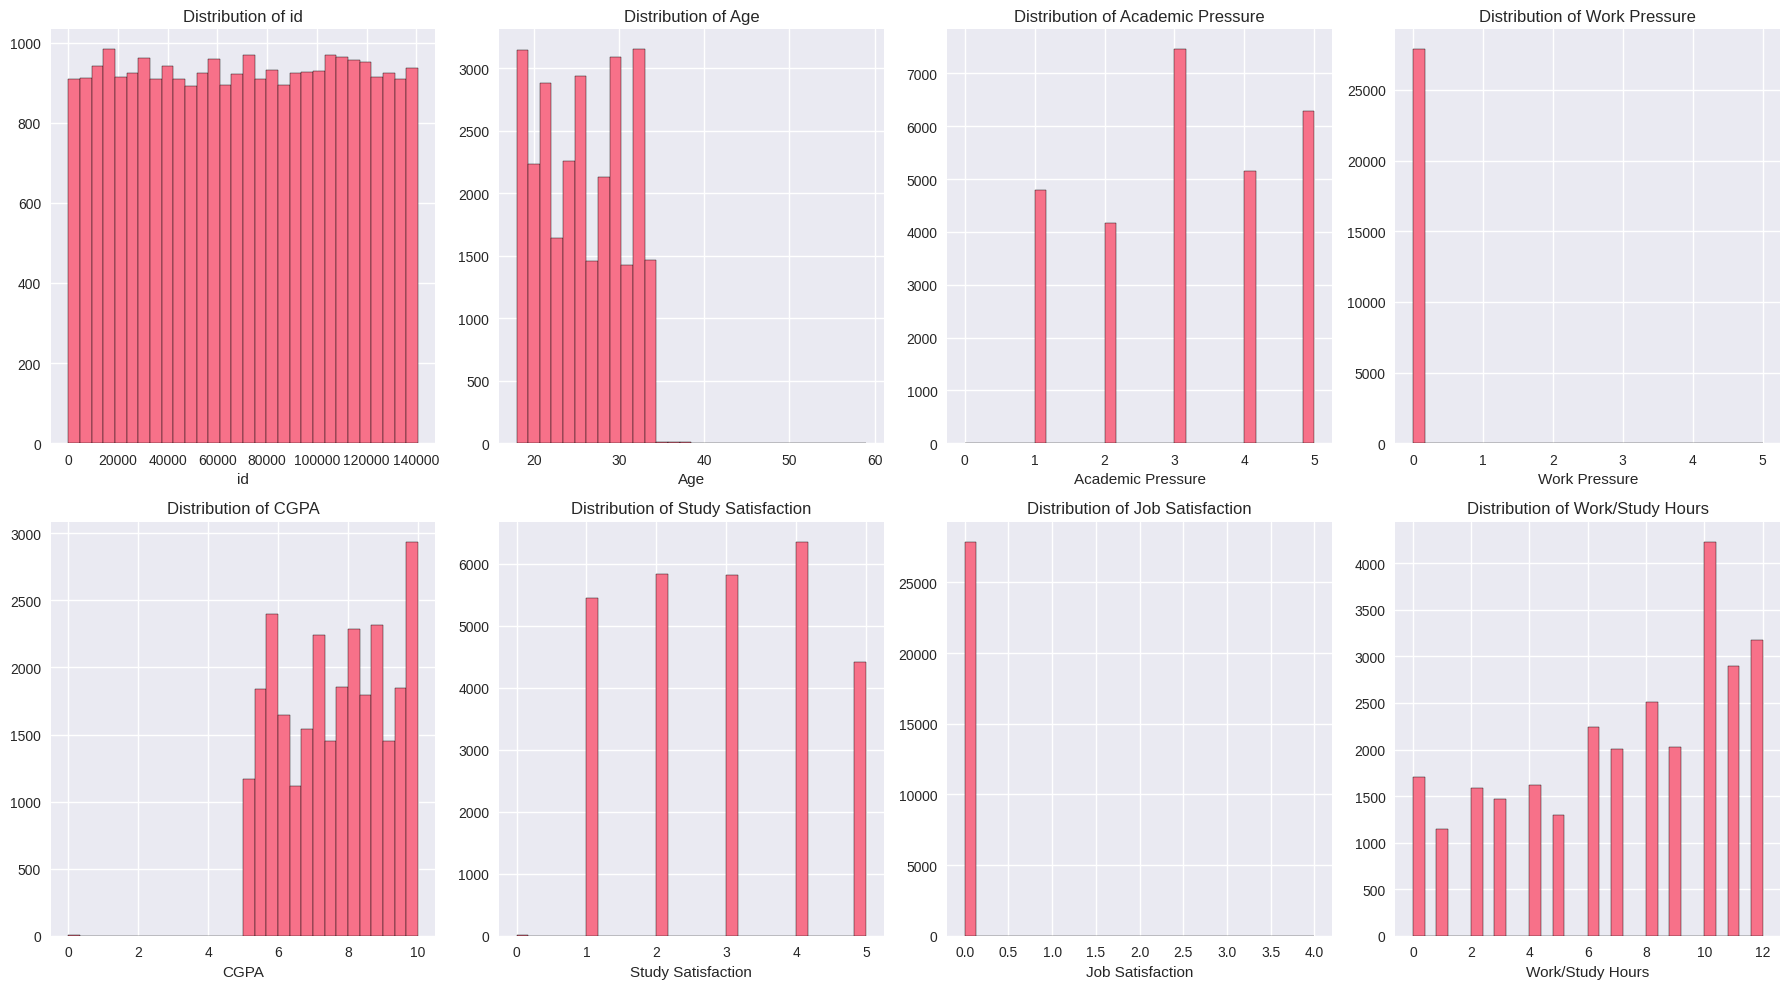

In [ ]:
from matplotlib.ticker import FuncFormatter


fig, axes = plt.subplots(2, 4, figsize=(18, 10))  # 2 hàng x 4 cột cho 8 biến

for i, col in enumerate(numeric_feature):
    row, col_idx = divmod(i, 4)   # 4 cột mỗi hàng
    clean_data = df[col].dropna()

    # Histogram trực tiếp (không log-transform)
    axes[row, col_idx].hist(clean_data, bins=30, edgecolor="black")

    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


### Phân tích Boxplot cho các biến số

Kết quả boxplot cho thấy:  
- `id`: phân phối khá đồng đều và đối xứng.
- `Age`: hầu như tập trung ở độ tuổi khoảng 20-30 là chủ yếu. Vẫn có tồn tại outlier, tuy nhiên số lượng không quá đáng kể khi so với phần còn lại của dữ liệu.
- `Academic Pressure`: tập trung nhiều ở mức 2-4 và có su hướng lệch sang phải.
-`Work Pressure`: gần như tất cả đều nằm ở mức 0, có vài trường hợp cá biệt ở mức cao hơn, tuy nhiên điều này có thể giải thích vì đối tượng khảo sát chính đa phần vẫn còn là học sinh sinh viên, phần nhiều chưa thực sự bước chân vào thị trường lao động.
- `CGPA`: tập trung nhiều ở các giá trị khoảng 8, điểm trung bình tích lũy bị lệch phải.
- `Study Satisfaction`: tập trung nhiều ở mức 2-4 và có su hướng lệch sang phải.
-`Job Satisfaction`: gần như tất cả đều nằm ở mức 0, có vài trường hợp cá biệt ở mức cao hơn, tuy nhiên điều này có thể giải thích vì đối tượng khảo sát chính đa phần vẫn còn là học sinh sinh viên, phần nhiều chưa thực sự bước chân vào thị trường lao động.
- `Work/Study Hours`: thời gian học tập, làm việc chủ yếu tập trung từ 4-10h trong một ngày và dữ liệu có xu hướng lệch phải.


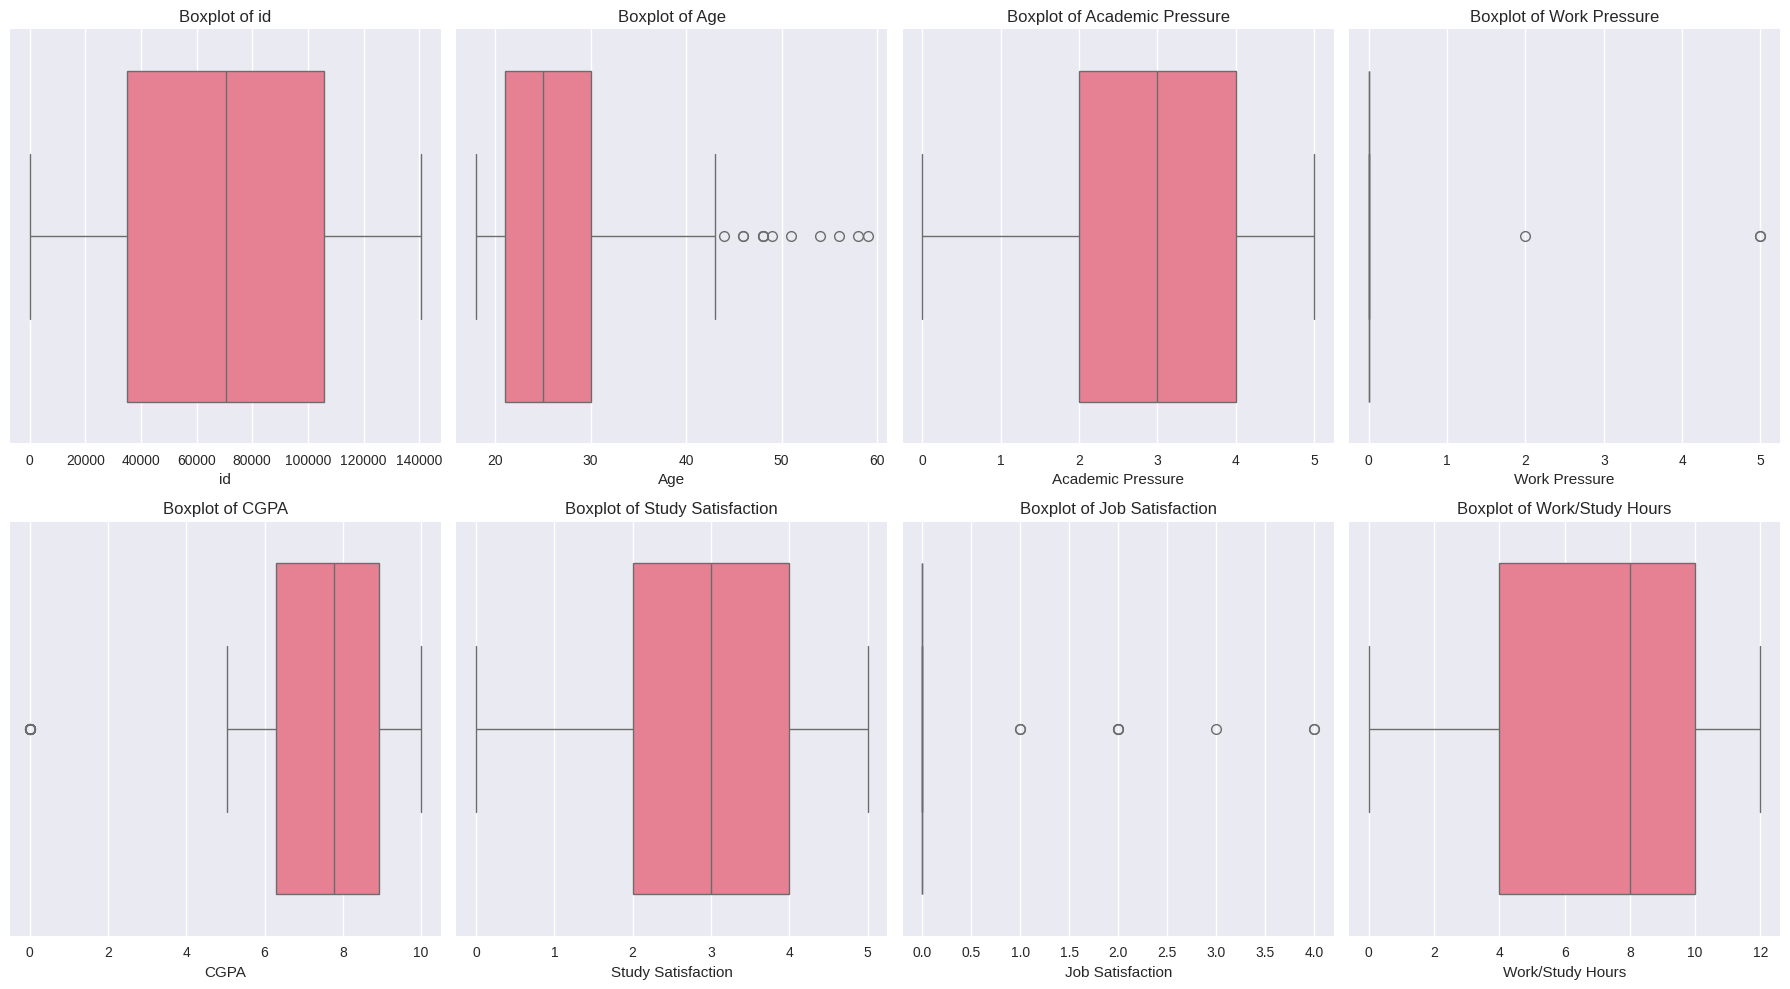

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))  # 2 hàng x 4 cột cho 8 biến

for i, col in enumerate(numeric_feature):
    row, col_idx = divmod(i, 4)  # vì mỗi hàng có 4 cột
    clean_data = df[col].dropna()

    sns.boxplot(x=clean_data, ax=axes[row, col_idx])
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
outlier_counts = {}

for col in numeric_feature:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_counts[col] = len(outliers)

# Hiển thị kết quả
for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")

id: 0 outliers
Age: 12 outliers
Academic Pressure: 0 outliers
Work Pressure: 3 outliers
CGPA: 9 outliers
Study Satisfaction: 0 outliers
Job Satisfaction: 8 outliers
Work/Study Hours: 0 outliers


## *Thống kê mô tả với biến còn lại*



### Nhận xét tổng quan về biến phân loại

**Gender (Giới tính):**  
- Phân bố cân bằng: **Male = 15547**, **Female = 12354** → không thiên lệch lớn.

**City (Thành phố):**  
- Có 52 giá trị khác nhau. Một số thành phố lớn nhất: Kalyan (1570), Srinagar (1372), Hyderabad (1340), Vasai-Virar (1290), Lucknow (1155).  
- Dữ liệu phân bố khá đa dạng nhưng vẫn tập trung nhiều ở các thành phố lớn.

**Profession (Nghề nghiệp):**  
- 14 giá trị khác nhau. Chủ yếu là **Student (27870)**, các nghề khác rất ít mẫu → nghề nghiệp ít ảnh hưởng do số lượng quá nhỏ.

**Sleep Duration (Thời gian ngủ):**  
- 5 giá trị khác nhau, phân bố: Less than 5 hours (8310), 7-8 hours (7346), 5-6 hours (6183), More than 8 hours (6044), Others (18).  
- Dữ liệu trải đều, số lượng cực nhỏ ở category “Others”.

**Dietary Habits (Thói quen ăn uống):**  
- 4 giá trị: Unhealthy (10317), Moderate (9921), Healthy (7651), Others (12).  
- Phần lớn bệnh nhân thuộc nhóm Unhealthy/Moderate.

**Degree (Trình độ học vấn):**  
- 28 giá trị khác nhau. Nhóm phổ biến: Class 12 (6080), B.Ed (1867), B.Com (1506), B.Arch (1478), BCA (1433), MSc (1190).  
- Phân bố khá đa dạng, có nhóm ít mẫu cần lưu ý.

**Have you ever had suicidal thoughts ? (Từng nghĩ đến tự sát):**  
- 2 giá trị: Yes (17656), No (10245).  
- Tỷ lệ Yes chiếm ~63% → cân nhắc khi phân tích tác động tới Depression.

**Financial Stress (Căng thẳng tài chính):**  
- 6 giá trị: 1.0 → 5.0.  

**Family History of Mental Illness (Tiền sử bệnh tâm thần gia đình):**  
- 2 giá trị: No (14398), Yes (13503) → ~50/50, cân bằng tốt.

**Depression (Trầm cảm):**  
- 2 giá trị: 1 (16336), 0 (11565) → gần cân bằng, có thể dùng trực tiếp làm target.

---

### Kết luận
- Các biến **Gender, Family History, Depression** phân bố khá cân bằng, thuận lợi cho mô hình hóa.  
- Một số biến categorical có nhiều giá trị (City, Degree) hoặc phân bố lệch (Profession) → cần xem xét **mã hóa hợp lý hoặc gom nhóm category nhỏ**.  



In [ ]:
# Danh sách biến categorical trong bộ dữ liệu Asthma
categorical_feature = [
    "Gender", "City", "Profession", "Sleep Duration", "Dietary Habits",
    "Degree", "Have you ever had suicidal thoughts ?",
    "Financial Stress", "Family History of Mental Illness", "Depression"
]

# Thống kê tần suất xuất hiện
for col in categorical_feature:
    print(f"================== Thống kê biến: {col} ==================")
    print("Số lượng giá trị unique:", df[col].nunique())
    print("Số lượng giá trị khuyết:", df[col].isna().sum())
    display(df[col].value_counts().head(10))
    print("\n")


================== Thống kê biến: Gender ==================
Số lượng giá trị unique: 2
Số lượng giá trị khuyết: 0


,count
Gender,
Male,15547
Female,12354




================== Thống kê biến: City ==================
Số lượng giá trị unique: 52
Số lượng giá trị khuyết: 0


,count
City,
Kalyan,1570
Srinagar,1372
Hyderabad,1340
Vasai-Virar,1290
Lucknow,1155
Thane,1139
Ludhiana,1111
Agra,1094
Surat,1078




================== Thống kê biến: Profession ==================
Số lượng giá trị unique: 14
Số lượng giá trị khuyết: 0


...

,count
Financial Stress,
5.0,6715
4.0,5775
3.0,5226
1.0,5121
2.0,5061
?,3




================== Thống kê biến: Family History of Mental Illness ==================
Số lượng giá trị unique: 2
Số lượng giá trị khuyết: 0


,count
Family History of Mental Illness,
No,14398
Yes,13503




================== Thống kê biến: Depression ==================
Số lượng giá trị unique: 2
Số lượng giá trị khuyết: 0


,count
Depression,
1,16336
0,11565


## *Lựa chọn các cột cần thiết*
Sau khi khảo sát sơ bộ, nhóm tiến hành bước tiền xử lý dữ liệu để đảm bảo chất lượng và tính phù hợp cho mô hình dự đoán.  

### **Phần Giữ lại**
Các đặc trưng quan trọng, có thể được cho là nguyên nhân gián tiếp hoặc trực tiếp dẫn đến trầm cảm được giữ lại bao gồm:  
- `Work/Study Hours`: thời gian học tập, làm việc.  
- `Financial Stress`: căng thẳng tài chính.
- `Academic Pressure`: áp lực học tập.
- `CGPA`: điểm trung bình tích lũy.
- `Study Satisfaction`: mức độ thỏa mãn với học tập.
- `Have you ever had suicidal thoughts ?`: suy nghĩ tự tử.
- `Depression`: trầm cảm hay không.

### **Phần Loại bỏ**
Loại bỏ các biến không liên quan, có dữ liệu thu thập không hợp lý
- `id`: chỉ có ý nghĩa trong việc phân loại từng người, không có ý nghĩa phân định việc trầm cảm hay không.
- `Age`: tuổi tác không thực sự ảnh hưởng quá lớn đến việc trầm cảm.
-`Work Pressure`:lứa tuổi chủ yếu trong bài này chỉ là học sinh, sinh viên nên biến này rất như không có ý nghĩa khi phần lớn các đối tượng chưa đi làm.
-`Job Satisfaction`: giống với biến `Work Pressure`, không có quá nhiều ý nghĩa khi hần lớn đều chưa đi làm.
-`Gender`: giới tính không thực sự ảnh hưởng trực tiếp hay gián tiếp với bất kỳ biến nào trong đây.
-`City`: chỉ có tác dụng phân định khu vực sống, khá chung chung nên cũng không thực sự tác động đến bất kỳ yếu tố nào.
-`Profession`: không thực sự ảnh hưởng trực tiếp hay gián tiếp lên bất kỳ biến nào.
-`Sleep Duration`: biến này thay vì là nguyên nhân của `Depression` thì lại là kết quả của nó.
-`Dietary Habits`: không thực sự ảnh hưởng trực tiếp hay gián tiếp lên bất kỳ biến nào.
-`Degree`: không thực sự ảnh hưởng trực tiếp hay gián tiếp lên bất kỳ biến nào.
-`Family History of Mental Illness`:  không thực sự ảnh hưởng trực tiếp hay gián tiếp lên bất kỳ biến nào.

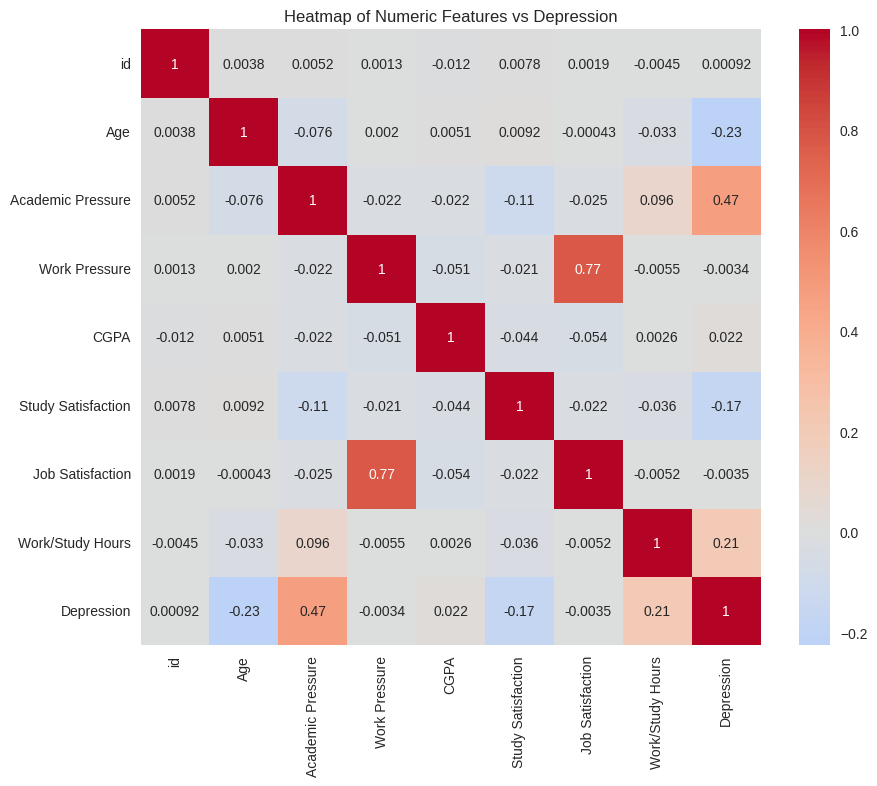

In [ ]:
numeric_feature = [
    "id", "Age", "Academic Pressure", "Work Pressure", "CGPA",
    "Study Satisfaction", "Job Satisfaction",
    "Work/Study Hours"
]

corr = df[numeric_feature + ["Depression"]].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Heatmap of Numeric Features vs Depression")
plt.show()

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

categorical_feature = [
    "Gender", "City", "Profession", "Sleep Duration", "Dietary Habits",
    "Degree", "Have you ever had suicidal thoughts ?",
    "Financial Stress", "Family History of Mental Illness"
]

X_cat = df[categorical_feature].copy()
y = df["Depression"]

for col in X_cat.columns:
    X_cat[col] = pd.factorize(X_cat[col])[0]

mi = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42)

mi_series = pd.Series(mi, index=categorical_feature).sort_values(ascending=False)
print(mi_series)


Have you ever had suicidal thoughts ?    0.154642
Financial Stress                         0.068728
Dietary Habits                           0.021837
Degree                                   0.009772
Sleep Duration                           0.004962
City                                     0.003534
Family History of Mental Illness         0.001429
Profession                               0.000359
Gender                                   0.000002
dtype: float64


Xử lý dữ liệu

In [ ]:
!git clone https://github.com/HuynhNhan27/BTL_ML_251

Cloning into 'BTL_ML_251'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 90 (delta 25), reused 73 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 7.58 MiB | 6.38 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [ ]:
from BTL_ML_251.modules import tabular

In [ ]:
cols = ["Work/Study Hours",
        "Sleep Duration", "CGPA",
        "Have you ever had suicidal thoughts ?",
        "Financial Stress", "Academic Pressure",
        "Study Satisfaction",
        "Depression",
        "Age",
        "Dietary Habits",]
data = df[cols]

In [ ]:
data["CGPA"] = pd.cut(x=data["CGPA"], bins=5)
data["Age"] = pd.cut(x=data["Age"], bins=5)

In [ ]:
data

,Work/Study Hours,Sleep Duration,CGPA,Have you ever had suicidal thoughts ?,Financial Stress,Academic Pressure,Study Satisfaction,Depression,Age,Dietary Habits
0,3.0,'5-6 hours',"(8.0, 10.0]",Yes,1.0,5.0,2.0,1,"(26.2, 34.4]",Healthy
1,3.0,'5-6 hours',"(4.0, 6.0]",No,2.0,2.0,5.0,0,"(17.959, 26.2]",Moderate
2,9.0,'Less than 5 hours',"(6.0, 8.0]",No,1.0,3.0,5.0,0,"(26.2, 34.4]",Healthy
3,4.0,'7-8 hours',"(4.0, 6.0]",Yes,5.0,3.0,2.0,1,"(26.2, 34.4]",Moderate
4,1.0,'5-6 hours',"(8.0, 10.0]",Yes,1.0,4.0,3.0,0,"(17.959, 26.2]",Moderate
...,...,...,...,...,...,...,...,...,...,...
27896,7.0,'5-6 hours',"(4.0, 6.0]",Yes,1.0,5.0,5.0,0,"(26.2, 34.4]",Unhealthy
27897,0.0,'Less than 5 hours',"(8.0, 10.0]",No,3.0,2.0,3.0,0,"(26.2, 34.4]",Healthy
27898,12.0,'5-6 hours',"(6.0, 8.0]",No,2.0,3.0,4.0,0,"(26.2, 34.4]",Unhealthy
27899,10.0,'Less than 5 hours',"(6.0, 8.0]",Yes,5.0,5.0,2.0,1,"(17.959, 26.2]",Healthy


In [ ]:
data = data.astype("object")

In [ ]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
data2 = data.copy()

cols_to_drop = [
    "Dietary Habits",
    "Financial Stress",
    "Sleep Duration",
    "CGPA"
]

data2 = data2.drop(columns=cols_to_drop)

train_data2, test_data2 = train_test_split(data2, test_size=0.2, random_state=42)

In [ ]:
train_data2

,Work/Study Hours,Have you ever had suicidal thoughts ?,Academic Pressure,Study Satisfaction,Depression,Age
13048,4.0,No,2.0,5.0,0,"(26.2, 34.4]"
24535,12.0,No,4.0,4.0,0,"(26.2, 34.4]"
15303,12.0,Yes,4.0,4.0,1,"(26.2, 34.4]"
22444,10.0,No,2.0,4.0,0,"(26.2, 34.4]"
18744,11.0,Yes,5.0,5.0,1,"(17.959, 26.2]"
...,...,...,...,...,...,...
21575,10.0,No,2.0,4.0,1,"(26.2, 34.4]"
5390,3.0,No,3.0,1.0,0,"(17.959, 26.2]"
860,6.0,Yes,5.0,3.0,1,"(17.959, 26.2]"
15795,0.0,Yes,3.0,4.0,0,"(17.959, 26.2]"


# **📊 Huấn luyện mô hình**

Xây dựng mạng bayesian network dựa trên mô hình

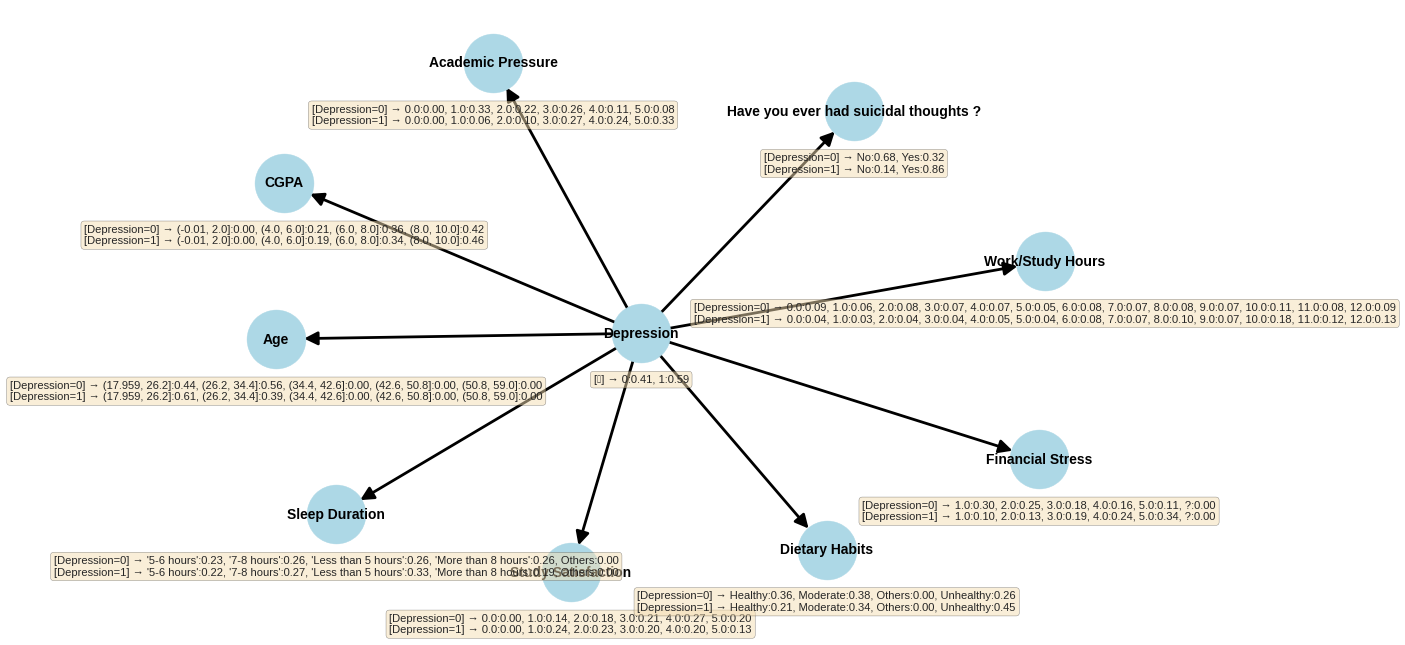

{'Accuracy': 0.8331840172012184}

In [ ]:
bnt = BayesianNetworkTable(train_data)
bnt.add_variable_from_data("Depression")
bnt.add_variable_from_data("Work/Study Hours", ["Depression"])
bnt.add_variable_from_data("Sleep Duration", ["Depression"])
bnt.add_variable_from_data("CGPA", ["Depression"])
bnt.add_variable_from_data("Have you ever had suicidal thoughts ?", ["Depression"])
bnt.add_variable_from_data("Academic Pressure", ["Depression"])
bnt.add_variable_from_data("Financial Stress", ["Depression"])
bnt.add_variable_from_data("Study Satisfaction", ["Depression"])
bnt.add_variable_from_data("Age", ["Depression"])
bnt.add_variable_from_data("Dietary Habits", ["Depression"])
bnt.fit_all()
bnt.visualize(hide_table = False)
bnt.evaluate("Depression", test_data, method="approximate", N = 100)

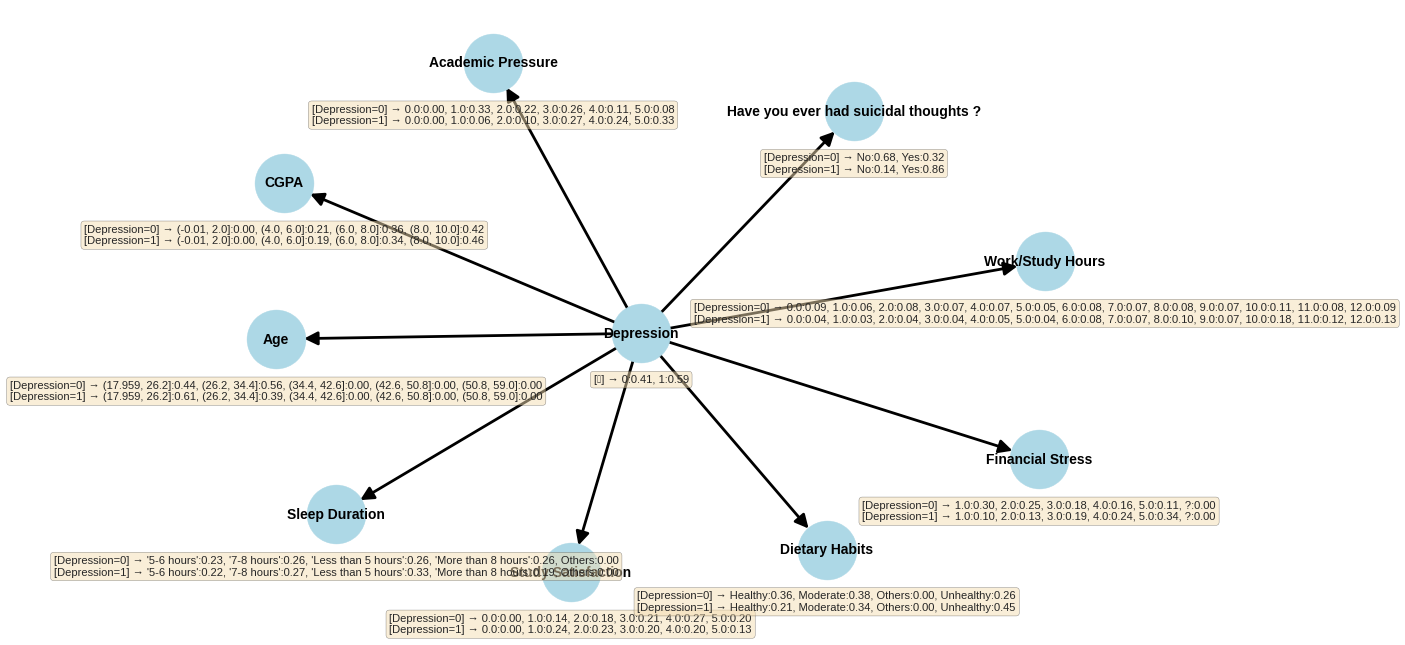

{'Accuracy': 0.8362300662963627}

In [ ]:
bnt = BayesianNetworkTable(train_data)
bnt.add_variable_from_data("Depression")
bnt.add_variable_from_data("Work/Study Hours", ["Depression"])
bnt.add_variable_from_data("Sleep Duration", ["Depression"])
bnt.add_variable_from_data("CGPA", ["Depression"])
bnt.add_variable_from_data("Have you ever had suicidal thoughts ?", ["Depression"])
bnt.add_variable_from_data("Academic Pressure", ["Depression"])
bnt.add_variable_from_data("Financial Stress", ["Depression"])
bnt.add_variable_from_data("Study Satisfaction", ["Depression"])
bnt.add_variable_from_data("Age", ["Depression"])
bnt.add_variable_from_data("Dietary Habits", ["Depression"])
bnt.fit_all(method="MLE", smoothing=0.1)
bnt.visualize(hide_table = False)
bnt.evaluate("Depression", test_data, method="approximate", N = 100)

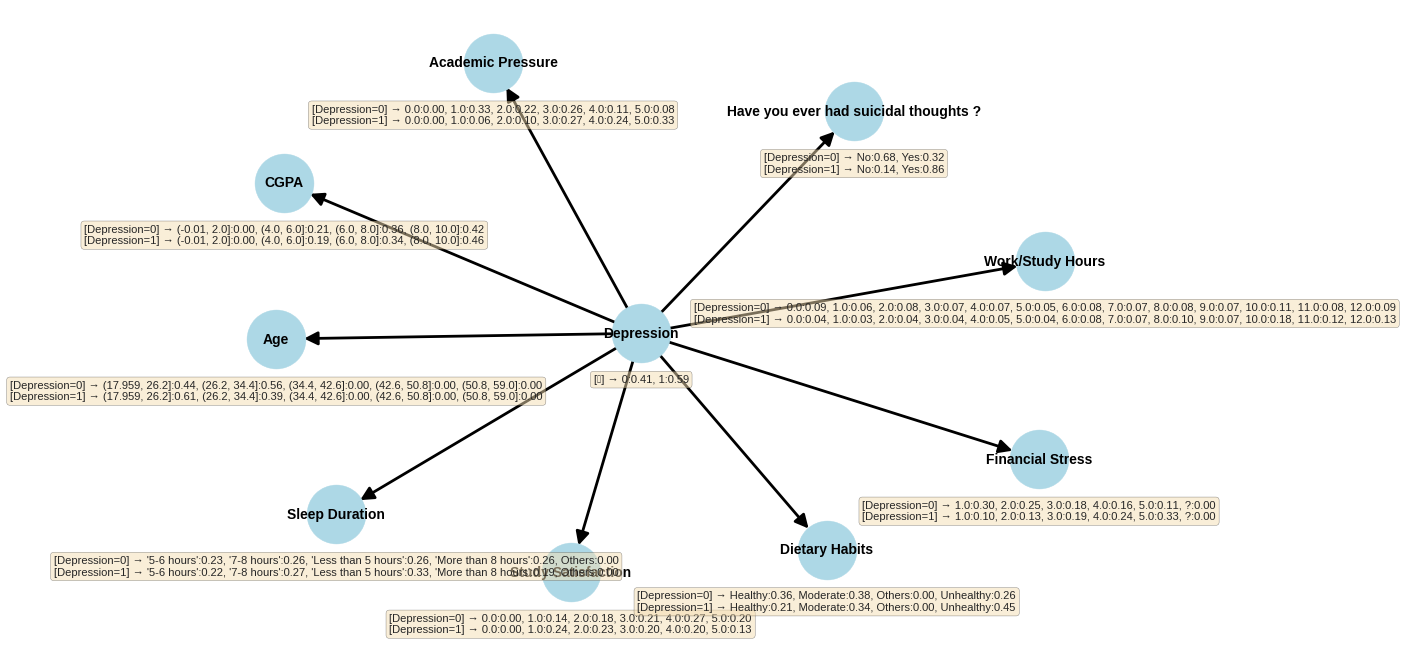

{'Accuracy': 0.8364092456549006}

In [ ]:
bnt = BayesianNetworkTable(train_data)
bnt.add_variable_from_data("Depression")
bnt.add_variable_from_data("Work/Study Hours", ["Depression"])
bnt.add_variable_from_data("Sleep Duration", ["Depression"])
bnt.add_variable_from_data("CGPA", ["Depression"])
bnt.add_variable_from_data("Have you ever had suicidal thoughts ?", ["Depression"])
bnt.add_variable_from_data("Academic Pressure", ["Depression"])
bnt.add_variable_from_data("Financial Stress", ["Depression"])
bnt.add_variable_from_data("Study Satisfaction", ["Depression"])
bnt.add_variable_from_data("Age", ["Depression"])
bnt.add_variable_from_data("Dietary Habits", ["Depression"])
bias = {
    "Have you ever had suicidal thoughts ?": {
        (1,): {"Yes": 3, "No": 1},
        (0,):  {"Yes": 1, "No": 5}
    },
}
bnt.fit_all(method="MAP", alpha=1.0, bias_table=bias)
bnt.visualize(hide_table = False)
bnt.evaluate("Depression", test_data, method="approximate", N = 100)

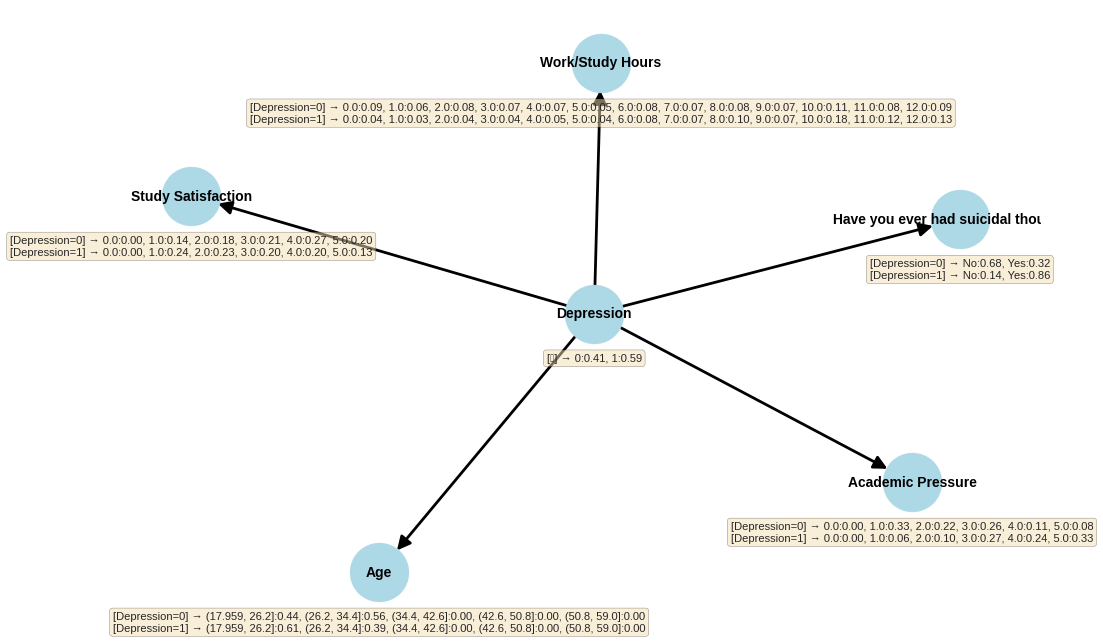

{'Accuracy': 0.8125783909693604}

In [ ]:
bnt = BayesianNetworkTable(train_data2)
bnt.add_variable_from_data("Work/Study Hours")
bnt.add_variable_from_data("Academic Pressure")
bnt.add_variable_from_data("Age")
bnt.add_variable_from_data("Depression")
bnt.add_variable_from_data("Work/Study Hours", ["Depression"])
bnt.add_variable_from_data("Have you ever had suicidal thoughts ?", ["Depression"])
bnt.add_variable_from_data("Academic Pressure", ["Depression"])
bnt.add_variable_from_data("Study Satisfaction", ["Depression"])
bnt.add_variable_from_data("Age", ["Depression"])

bnt.fit_all(method="MLE", smoothing=0.2)
bnt.visualize(hide_table=False)
bnt.evaluate("Depression", test_data2, method="exact")

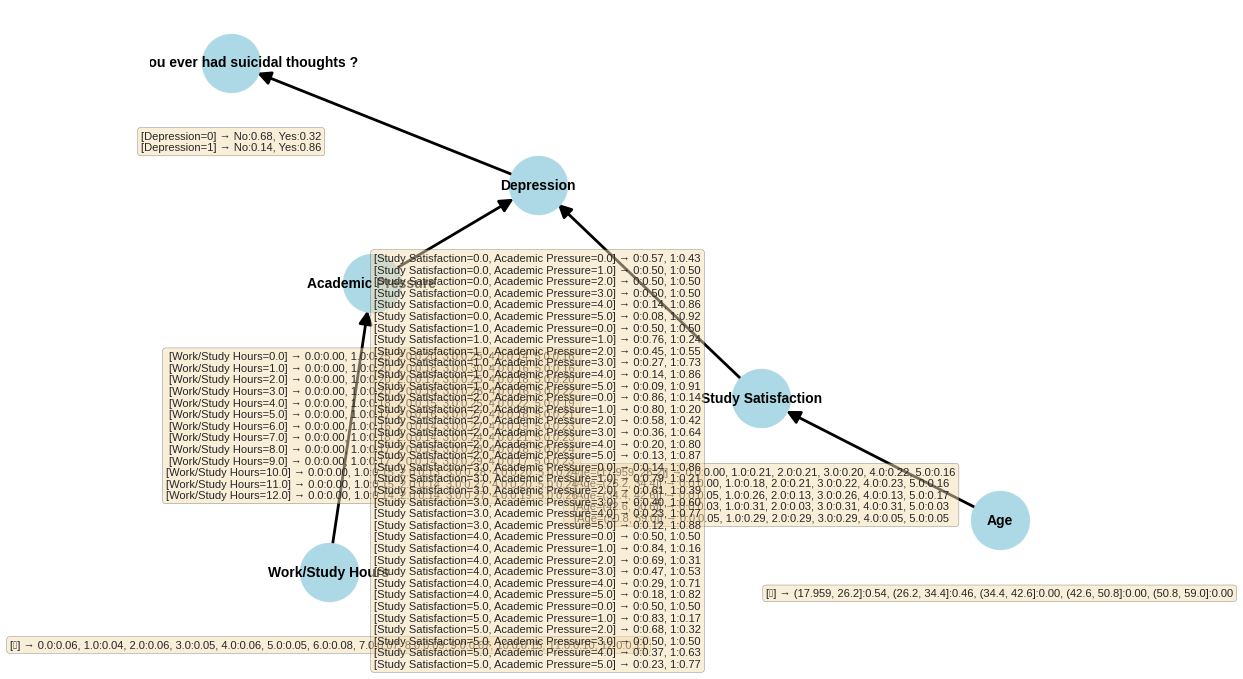

{'Accuracy': 0.8005733739473213}

In [ ]:
bnt = BayesianNetworkTable(train_data2)

bnt.add_variable_from_data("Age")
bnt.add_variable_from_data("Work/Study Hours")
bnt.add_variable_from_data("Academic Pressure", ["Work/Study Hours"])
bnt.add_variable_from_data("Study Satisfaction", ["Age"])
bnt.add_variable_from_data("Depression", ["Study Satisfaction", "Academic Pressure"])
bnt.add_variable_from_data("Have you ever had suicidal thoughts ?", ["Depression"])
bnt.fit_all(method="MLE", smoothing=0.2)
bnt.visualize(hide_table=False)
bnt.evaluate("Depression", test_data2, method="log")